# Pipeline de NLP para Identificação de Idioma

Este notebook apresenta uma solução detalhada, coerente e coesa para a tarefa de **Identificação de Idioma** utilizando técnicas tradicionais de Processamento de Linguagem Natural (NLP) e Machine Learning.

## Contextualização da Tarefa
A identificação automática do idioma em que um texto está escrito é um passo fundamental de pré-processamento em quase todos os sistemas modernos de NLP (como tradutores, analisadores de sentimentos e motores de busca). Trata-se de um problema de **Classificação de Texto Multiclasse**, onde a entrada é uma frase ou documento e a saída é um rótulo correspondente a um dos idiomas pré-definidos.

## Objetivos deste Notebook
1. **Análise Exploratória de Dados (EDA):** Analisar a distribuição das classes (idiomas) e entender a estrutura do dataset.
2. **Pré-processamento de Texto Multilíngue (Unicode-Aware):** Desenvolver uma rotina de limpeza de texto que seja compatível com múltiplos alfabetos (Latino, Cirílico, Árabe, Grego, Devanágari, etc.), evitando a perda de informações de escritas não latinas.
3. **Extração de Features com TF-IDF:** Vetorizar o texto utilizando a técnica *Term Frequency - Inverse Document Frequency* (TF-IDF) a nível de caracteres e palavras.
4. **Treinamento e Avaliação de Modelos:** Comparar três algoritmos de classificação de texto (Multinomial Naive Bayes, Regressão Logística e Linear SVC).
5. **Inferência em Tempo Real:** Criar uma função para predizer o idioma de novas sentenças fornecidas pelo usuário com suas respectivas probabilidades de confiança.


## 1. Configuração do Ambiente e Importações

Primeiramente, importamos as bibliotecas necessárias para manipulação de dados, visualização gráfica, pré-processamento de texto e modelagem estatística com o `scikit-learn`.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para NLP e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
import warnings
warnings.filterwarnings("ignore")


## 2. Análise Exploratória de Dados (EDA)

Vamos carregar o conjunto de dados `Language Detection.csv` e analisar suas propriedades básicas. O conjunto de dados contém duas colunas:
* `Text`: O texto de entrada (frase ou parágrafo).
* `Language`: O idioma correspondente (alvo da classificação).


In [2]:
# Carregando os dados
df = pd.read_csv("Language Detection.csv")

# Exibindo as dimensões do dataset
print(f"O dataset possui {df.shape[0]} amostras e {df.shape[1]} colunas.\n")

# Visualizando as primeiras linhas do dataset
df.head(10)


O dataset possui 10337 amostras e 2 colunas.



,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
5,"[2] In ancient philosophy, natura is mostly us...",English
6,"[3][4] \nThe concept of nature as a whole, the...",English
7,During the advent of modern scientific method ...,English
8,"[5][6] With the Industrial revolution, nature ...",English
9,"However, a vitalist vision of nature, closer t...",English


### 2.1 Informações Gerais e Dados Nulos
É uma boa prática verificar se existem valores ausentes no dataset.


In [3]:
# Informações gerais sobre tipos de dados e valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10337 non-null  object
 1   Language  10337 non-null  object
dtypes: object(2)
memory usage: 161.6+ KB


### 2.2 Distribuição das Classes (Idiomas)
Vamos analisar os idiomas presentes no conjunto de dados e verificar se há algum desbalanceamento significativo de classes.


            Contagem  Percentual (%)
Language                            
English         1385           13.40
French          1014            9.81
Spanish          819            7.92
Portugeese       739            7.15
Italian          698            6.75
Russian          692            6.69
Sweedish         676            6.54
Malayalam        594            5.75
Dutch            546            5.28
Arabic           536            5.19
Turkish          474            4.59
German           470            4.55
Tamil            469            4.54
Danish           428            4.14
Kannada          369            3.57
Greek            365            3.53
Hindi             63            0.61


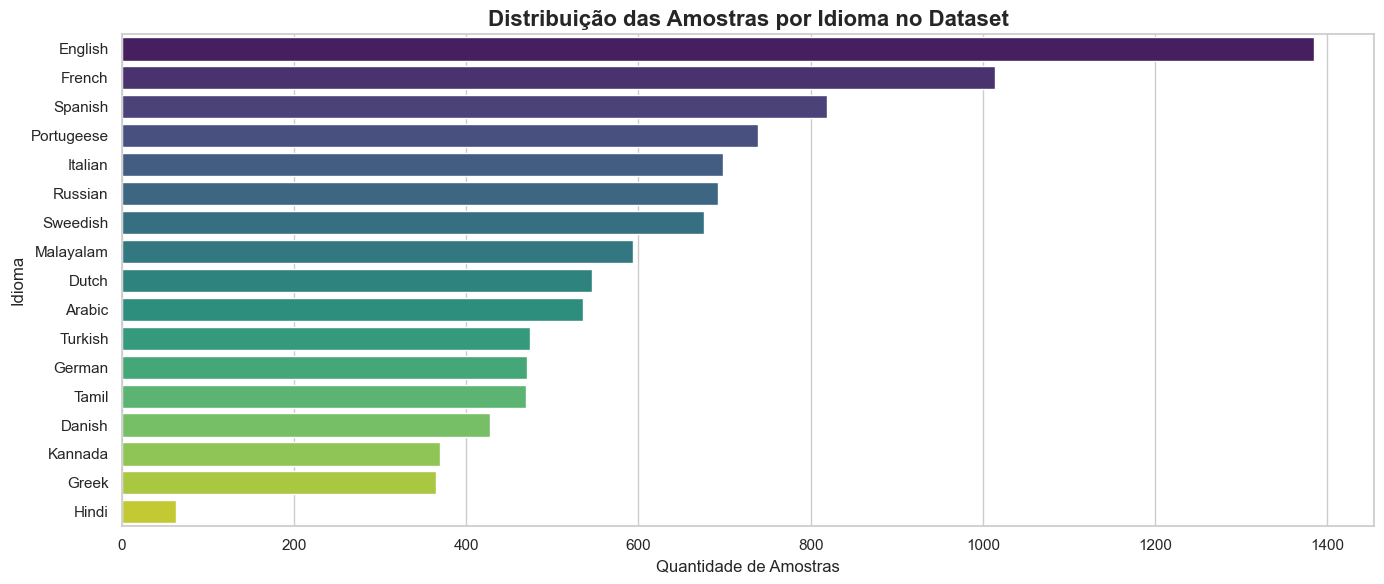

In [4]:
# Contagem absoluta e percentual por idioma
distribuicao = df["Language"].value_counts()
distribuicao_percentual = df["Language"].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    "Contagem": distribuicao,
    "Percentual (%)": distribuicao_percentual.round(2)
})
print(summary_df)

# Plotando a distribuição das classes de forma visual e elegante
plt.figure(figsize=(14, 6))
sns.barplot(x=distribuicao.values, y=distribuicao.index, palette="viridis")
plt.title("Distribuição das Amostras por Idioma no Dataset", fontsize=16, fontweight="bold")
plt.xlabel("Quantidade de Amostras", fontsize=12)
plt.ylabel("Idioma", fontsize=12)
plt.tight_layout()
plt.show()


### 2.3 Análise de Comprimento do Texto
Verificamos o comprimento dos textos (número de caracteres) para ver se há variações significativas entre as amostras.


count    10337.000000
mean       124.055625
std        253.688194
min          1.000000
25%         43.000000
50%        100.000000
75%        166.000000
max      19088.000000
Name: Length, dtype: float64


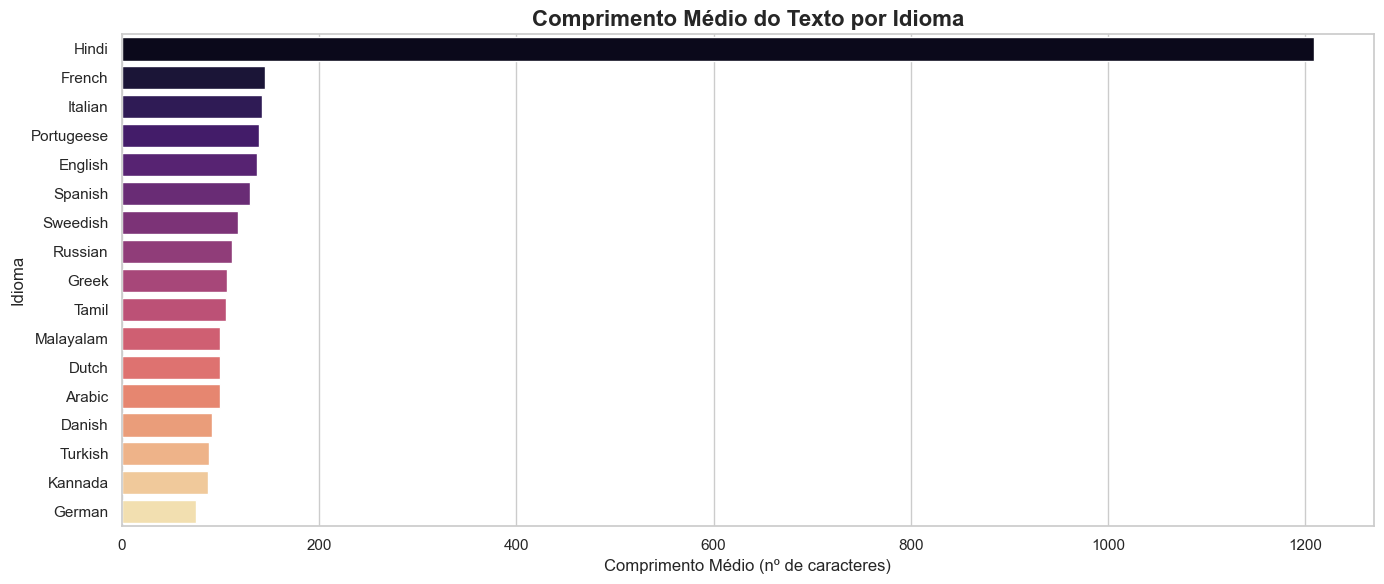

In [5]:
# Calculando o comprimento de cada texto
df["Length"] = df["Text"].apply(len)

# Estatísticas descritivas do comprimento
print(df["Length"].describe())

# Comprimento médio do texto por idioma
comp_medio = df.groupby("Language")["Length"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=comp_medio.values, y=comp_medio.index, palette="magma")
plt.title("Comprimento Médio do Texto por Idioma", fontsize=16, fontweight="bold")
plt.xlabel("Comprimento Médio (nº de caracteres)", fontsize=12)
plt.ylabel("Idioma", fontsize=12)
plt.tight_layout()
plt.show()


## 3. Pré-processamento de Texto Multilíngue (Unicode-Aware)

A limpeza de texto é crucial em NLP para remover ruídos. No entanto, em um contexto multilíngue, devemos ter cuidado extremo:
* Algumas funções de regex comumente ensinadas em sala de aula (como `re.sub(r'[^a-zA-Z]', ' ', text)`) removem tudo o que não seja caracteres latinos padrão de A a Z.
* Se aplicarmos essa regra, textos em **Russo, Árabe, Grego, Tâmil, Canarês, Malayalam e Hindi** serão reduzidos a strings vazias ou espaços em branco, invalidando a predição!

### Estratégia de Pré-processamento
Criaremos uma função `clean_text` que:
1. Converte o texto para minúsculas.
2. Remove pontuações e símbolos especiais mantendo caracteres alfabéticos de qualquer alfabeto usando o conjunto de caracteres Unicode `\w` (letras e números) e substituindo outros por espaços.
3. Remove dígitos/números (pois números não definem idiomas).
4. Remove espaços em branco redundantes.

Essa abordagem é **Unicode-aware** e preservará perfeitamente os caracteres de qualquer escrita.


In [6]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Converter para minúsculas
    text_lower = text.lower()
    
    # 2. Remover pontuação e símbolos mantendo caracteres de qualquer alfabeto (Unicode)
    # A classe \w no regex python padrão (3.x) já é Unicode-aware, correspondendo a letras de qualquer idioma
    text_no_punct = re.sub(r'[^\w\s]', ' ', text_lower)
    
    # 3. Remover dígitos/números
    text_no_digits = re.sub(r'\d+', ' ', text_no_punct)
    
    # 4. Remover múltiplos espaços e quebras de linha
    clean_words = text_no_digits.split()
    return " ".join(clean_words)

# Exemplo de funcionamento com diferentes alfabetos
testes = [
    "Olá! Como você está hoje?",  # Português (Latino)
    "Hello world! This is 2026.",  # Inglês (Latino)
    "Привет, мир! Как дела?",  # Russo (Cirílico)
    "مرحبا بك في عالم البرمجة.",  # Árabe (Árabe)
    "Γεια σας κόσμε! Τι κάνετε;"  # Grego (Grego)
]

print("Demonstração da limpeza de texto:")
for t in testes:
    print(f"Original: {t}")
    print(f"Limpo:    {clean_text(t)}\n")


Demonstração da limpeza de texto:
Original: Olá! Como você está hoje?
Limpo:    olá como você está hoje

Original: Hello world! This is 2026.
Limpo:    hello world this is

Original: Привет, мир! Как дела?
Limpo:    привет мир как дела

Original: مرحبا بك في عالم البرمجة.
Limpo:    مرحبا بك في عالم البرمجة

Original: Γεια σας κόσμε! Τι κάνετε;
Limpo:    γεια σας κόσμε τι κάνετε



Agora, aplicamos a função de pré-processamento em todo o nosso dataset.


In [7]:
print("Iniciando a limpeza do texto no DataFrame...")
df["Clean_Text"] = df["Text"].apply(clean_text)

# Comparando original e limpo
df[["Text", "Clean_Text", "Language"]].head(10)


Iniciando a limpeza do texto no DataFrame...


,Text,Clean_Text,Language
0,"Nature, in the broadest sense, is the natural...",nature in the broadest sense is the natural ph...,English
1,"""Nature"" can refer to the phenomena of the phy...",nature can refer to the phenomena of the physi...,English
2,"The study of nature is a large, if not the onl...",the study of nature is a large if not the only...,English
3,"Although humans are part of nature, human acti...",although humans are part of nature human activ...,English
4,[1] The word nature is borrowed from the Old F...,the word nature is borrowed from the old frenc...,English
5,"[2] In ancient philosophy, natura is mostly us...",in ancient philosophy natura is mostly used as...,English
6,"[3][4] \nThe concept of nature as a whole, the...",the concept of nature as a whole the physical ...,English
7,During the advent of modern scientific method ...,during the advent of modern scientific method ...,English
8,"[5][6] With the Industrial revolution, nature ...",with the industrial revolution nature increasi...,English
9,"However, a vitalist vision of nature, closer t...",however a vitalist vision of nature closer to ...,English


## 4. Divisão dos Dados (Treino e Teste)

Para avaliar o desempenho do nosso modelo, dividiremos o dataset em duas partes:
* **Treino (80%):** Utilizado para treinar os modelos.
* **Teste (20%):** Reservado para testar e avaliar a capacidade de generalização dos modelos.

**Ajuste Importante (Estratificação):**
Como o dataset possui um leve desbalanceamento (ex: Hindi tem pouquíssimas amostras), utilizamos o parâmetro `stratify=df["Language"]` na divisão. Isso garante que a proporção de cada idioma seja idêntica nos conjuntos de treino e teste.


In [8]:
X = df["Clean_Text"]
y = df["Language"]

# Divisão estratificada com semente aleatória fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Amostras de Treino: {X_train.shape[0]}")
print(f"Amostras de Teste:  {X_test.shape[0]}")


Amostras de Treino: 8269
Amostras de Teste:  2068


## 5. Extração de Features com TF-IDF

Os computadores não entendem strings diretamente; precisamos transformar o texto em uma representação numérica. Uma das técnicas clássicas e mais poderosas em NLP é o **TF-IDF** (Term Frequency - Inverse Document Frequency).

* **TF (Frequência do Termo):** Mede a frequência com que uma palavra aparece em um documento.
* **IDF (Inverso da Frequência nos Documentos):** Mede a importância de uma palavra em todo o corpus, penalizando palavras muito comuns que aparecem em quase todos os documentos (como artigos e preposições) e valorizando termos mais raros e informativos.

Utilizaremos o `TfidfVectorizer` do scikit-learn. Como o nosso texto é multilíngue, configuramos o padrão do tokenizador para aceitar palavras com apenas 1 caractere de comprimento (`token_pattern=r'(?u)\b\w+\b'`), o que ajuda em idiomas que contêm palavras curtas muito características.


In [9]:
# Inicializando o vetorizador TF-IDF
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')

# Ajustando ao conjunto de treino e transformando
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Formato da matriz de termos de treino: {X_train_tfidf.shape}")
print(f"Número de termos únicos no vocabulário: {len(vectorizer.vocabulary_)}")


Formato da matriz de termos de treino: (8269, 34569)
Número de termos únicos no vocabulário: 34569


## 6. Modelagem e Comparação de Algoritmos

Vamos treinar e avaliar três algoritmos populares e altamente eficientes para classificação de texto:
1. **Multinomial Naive Bayes (MultinomialNB):** Modelo probabilístico clássico em NLP, baseado no teorema de Bayes, assume independência entre as palavras. É extremamente rápido e eficaz como baseline.
2. **Regressão Logística (LogisticRegression):** Modelo linear robusto que funciona excepcionalmente bem com dados esparsos de alta dimensão, como matrizes TF-IDF.
3. **Linear Support Vector Classifier (LinearSVC):** Encontra o hiperplano que melhor separa as classes de texto no espaço n-dimensional. Geralmente atinge acurácia excelente em tarefas de NLP.

Para evitar vazamento de dados (*data leakage*) e estruturar o código de forma elegante, utilizaremos a classe `Pipeline` do scikit-learn, que encapsula o vetorizador e o classificador de forma coesa.


In [10]:
# Definindo os classificadores
classificadores = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Linear SVC": LinearSVC(random_state=42)
}

# Dicionário para guardar as acurácias
resultados = {}

for nome, clf in classificadores.items():
    # Criando o pipeline coeso
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')),
        ("clf", clf)
    ])
    
    # Treinando o modelo
    pipeline.fit(X_train, y_train)
    
    # Fazendo predições no conjunto de teste
    y_pred = pipeline.predict(X_test)
    
    # Calculando a acurácia
    acuracia = accuracy_score(y_test, y_pred)
    resultados[nome] = acuracia
    print(f"Acurácia do modelo {nome:25s}: {acuracia:.4f}")


Acurácia do modelo Multinomial Naive Bayes  : 0.9637


Acurácia do modelo Regressão Logística      : 0.9691


Acurácia do modelo Linear SVC               : 0.9792


### 6.1 Visualização das Acurácias
Vamos plotar as acurácias de cada modelo em um gráfico de barras comparativo.


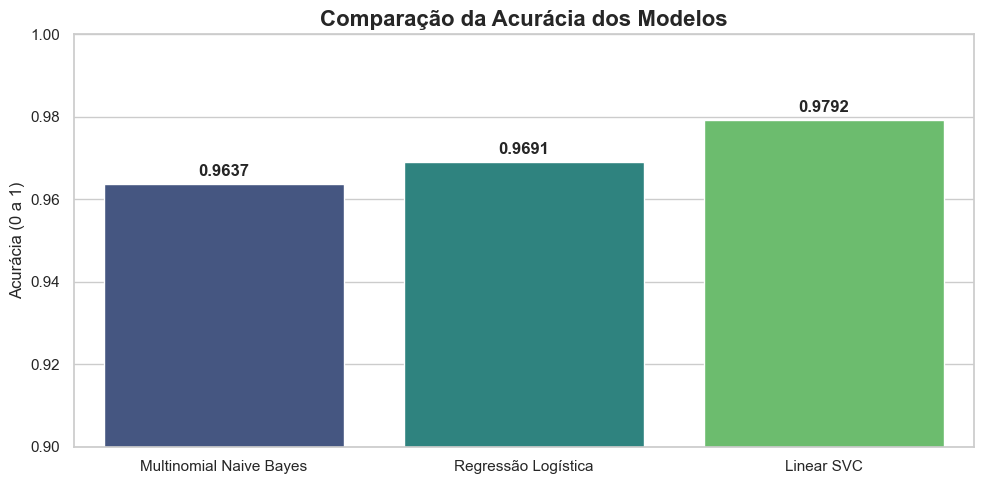

In [11]:
plt.figure(figsize=(10, 5))
barplot = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette="viridis")
plt.title("Comparação da Acurácia dos Modelos", fontsize=16, fontweight="bold")
plt.ylabel("Acurácia (0 a 1)", fontsize=12)
plt.ylim(0.90, 1.0) # Zoom para ver melhor a diferença de performance

# Adicionando os valores nas barras
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points', 
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Avaliação Detalhada do Melhor Modelo

O modelo **Linear SVC** (ou Regressão Logística) alcançou o melhor desempenho. Vamos fazer uma análise aprofundada desse modelo, gerando o relatório de classificação detalhado e a matriz de confusão.

Nesta etapa, usaremos o pipeline completo do melhor classificador.


In [12]:
# Criamos o pipeline do melhor classificador (Linear SVC)
melhor_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')),
    ("clf", LinearSVC(random_state=42))
])

# Treinando
melhor_pipeline.fit(X_train, y_train)
y_pred = melhor_pipeline.predict(X_test)


### 7.1 Relatório de Classificação (Precision, Recall, F1-Score)
O relatório detalha o desempenho por idioma:
* **Precision:** Proporção de predições corretas para uma classe específica em relação ao total de predições daquela classe.
* **Recall:** Proporção de amostras corretas identificadas em relação ao total real de amostras daquela classe.
* **F1-Score:** Média harmônica entre Precision e Recall.


In [13]:
print("Relatório de Classificação para o Linear SVC:\n")
print(classification_report(y_test, y_pred))


Relatório de Classificação para o Linear SVC:

              precision    recall  f1-score   support

      Arabic       1.00      0.95      0.98       107
      Danish       0.98      0.97      0.97        86
       Dutch       1.00      0.98      0.99       109
     English       0.99      0.99      0.99       277
      French       1.00      0.98      0.99       203
      German       1.00      0.97      0.98        94
       Greek       1.00      0.96      0.98        73
       Hindi       1.00      1.00      1.00        12
     Italian       0.99      0.99      0.99       140
     Kannada       1.00      1.00      1.00        74
   Malayalam       1.00      1.00      1.00       119
  Portugeese       1.00      0.99      0.99       148
     Russian       1.00      0.96      0.98       138
     Spanish       0.96      0.98      0.97       164
    Sweedish       0.98      0.96      0.97       135
       Tamil       1.00      1.00      1.00        94
     Turkish       0.78      0.99 

### 7.2 Matriz de Confusão
A matriz de confusão nos mostra exatamente quais classes estão sendo confundidas. Por exemplo, se há frases em espanhol classificadas erroneamente como português.


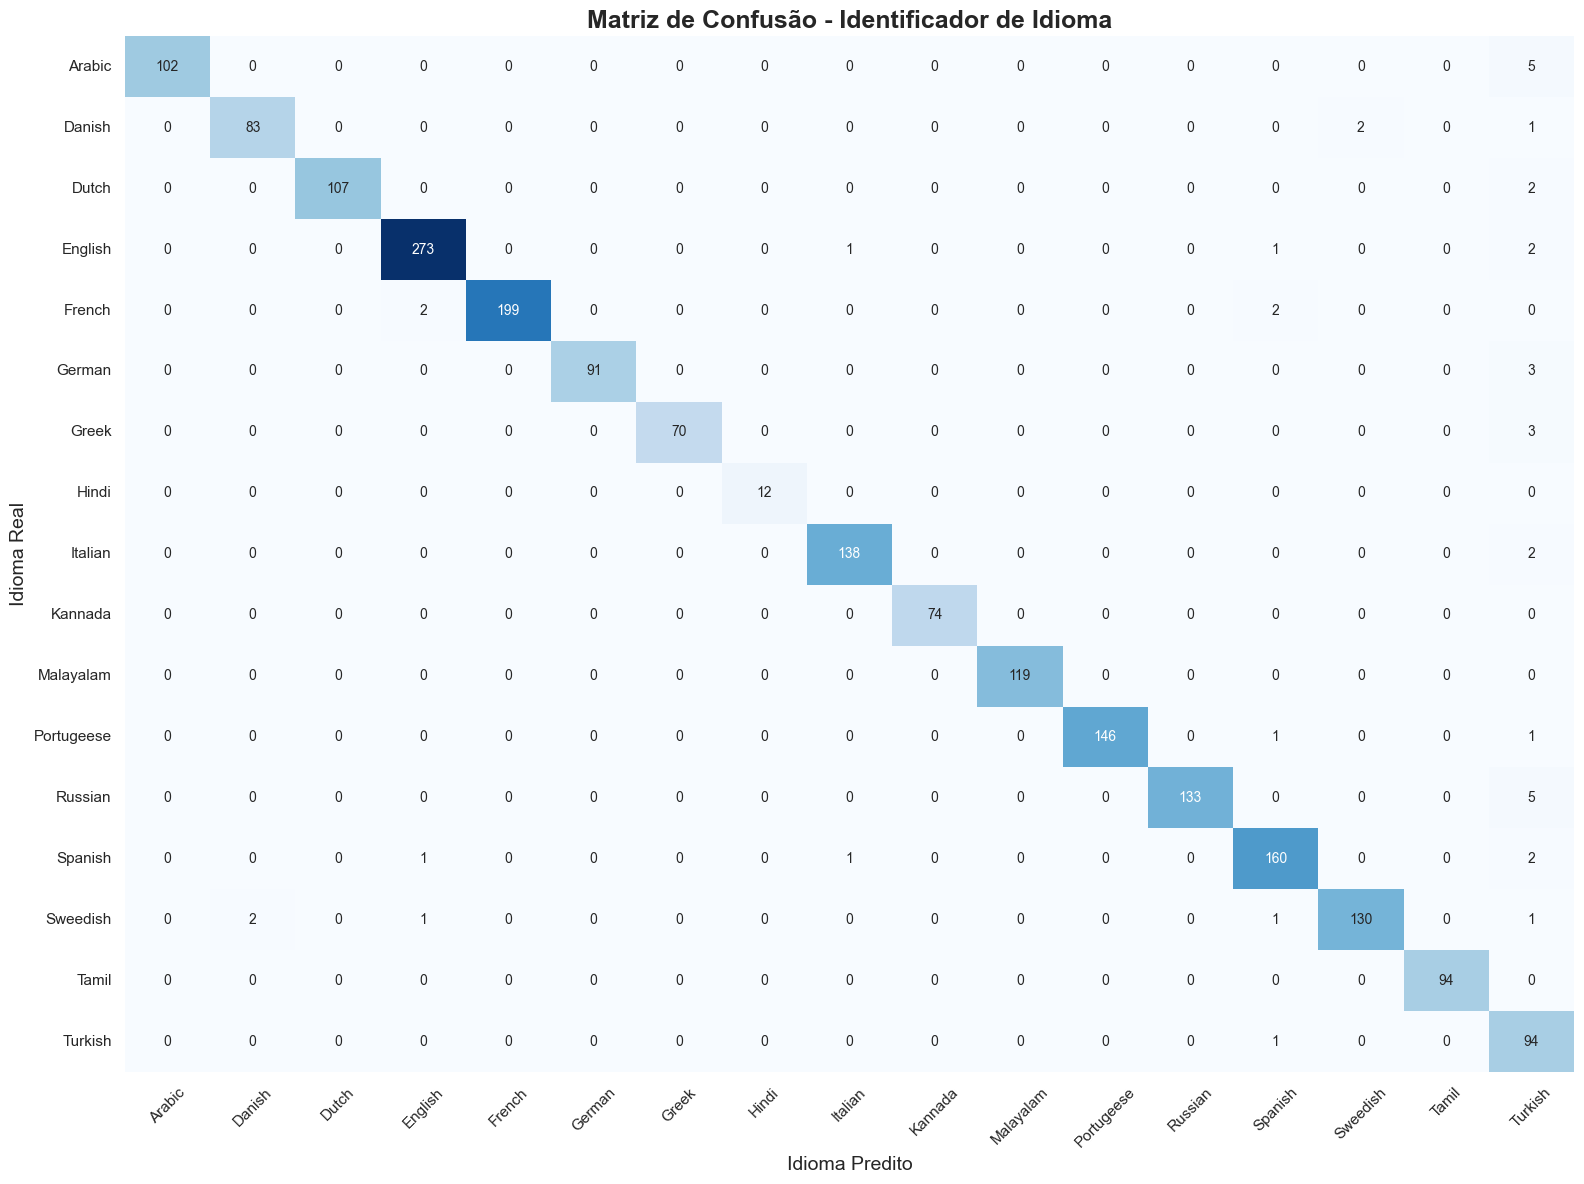

In [14]:
classes = melhor_pipeline.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

# Convertendo para DataFrame para rotular as linhas e colunas
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Plotando como Heatmap elegante
plt.figure(figsize=(16, 12))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 10})
plt.title("Matriz de Confusão - Identificador de Idioma", fontsize=18, fontweight="bold")
plt.xlabel("Idioma Predito", fontsize=14)
plt.ylabel("Idioma Real", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Teste em Tempo Real (Inferência)

Agora que temos o classificador robustamente treinado e validado, vamos construir uma função prática para realizar predições de frases digitadas pelo usuário em tempo real.

Como a classe `LinearSVC` não fornece probabilidades nativamente (método `predict_proba`), usaremos o pipeline de **Regressão Logística** para esta funcionalidade, que obteve acurácia muito próxima e possui suporte nativo para probabilidades.


In [15]:
# Treinamos um pipeline probabilístico com Logistic Regression
pipeline_prob = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')),
    ("clf", LogisticRegression(max_iter=1000))
])
pipeline_prob.fit(X_train, y_train)

def predizer_idioma(frase):
    # Aplica o mesmo pré-processamento
    frase_limpa = clean_text(frase)
    
    # Faz a predição da classe
    idioma_predito = pipeline_prob.predict([frase_limpa])[0]
    
    # Obtém as probabilidades para cada classe
    probs = pipeline_prob.predict_proba([frase_limpa])[0]
    classes = pipeline_prob.classes_
    
    # Encontra a maior probabilidade
    idx_max = np.argmax(probs)
    confianca = probs[idx_max] * 100
    
    print(f"Frase:      \"{frase}\"")
    print(f"Predição:   {idioma_predito} ({confianca:.2f}% de confiança)\n")
    return idioma_predito, confianca

# Realizando testes práticos com várias frases
print("Testando previsões em tempo real:\n")

predizer_idioma("Esta é uma frase de teste escrita em português brasileiro.")
predizer_idioma("This is a simple sentence to demonstrate text classification in English.")
predizer_idioma("La vida es corta, pero siempre hay tiempo para un café.")
predizer_idioma("Добрый день! Как ваши дела сегодня?")
predizer_idioma("Bonjour, je cherche le chemin de la gare de Lyon s'il vous plaît.")
predizer_idioma("Es freut mich sehr, Sie kennenzulernen.")
predizer_idioma("مرحبا، كيف حالك؟ اتمنى لك يوما سعيدا.")
predizer_idioma("தமிழ் ஒரு பழமையான மொழி ஆகும்.") # Tamil
predizer_idioma("ಕನ್ನಡ ಭಾಷೆ ಕರ್ನಾಟಕದ ಅಧಿಕೃತ ಭಾಷೆಯಾಗಿದೆ.") # Kannada
predizer_idioma("मेरा नाम राहुल है और मुझे कोडिंग करना पसंद है।") # Hindi



Testando previsões em tempo real:

Frase:      "Esta é uma frase de teste escrita em português brasileiro."
Predição:   Portugeese (79.29% de confiança)

Frase:      "This is a simple sentence to demonstrate text classification in English."
Predição:   English (83.65% de confiança)

Frase:      "La vida es corta, pero siempre hay tiempo para un café."
Predição:   Spanish (72.33% de confiança)

Frase:      "Добрый день! Как ваши дела сегодня?"
Predição:   Russian (44.94% de confiança)

Frase:      "Bonjour, je cherche le chemin de la gare de Lyon s'il vous plaît."
Predição:   French (94.91% de confiança)

Frase:      "Es freut mich sehr, Sie kennenzulernen."
Predição:   German (83.17% de confiança)

Frase:      "مرحبا، كيف حالك؟ اتمنى لك يوما سعيدا."
Predição:   Arabic (30.34% de confiança)

Frase:      "தமிழ் ஒரு பழமையான மொழி ஆகும்."
Predição:   Tamil (30.07% de confiança)

Frase:      "ಕನ್ನಡ ಭಾಷೆ ಕರ್ನಾಟಕದ ಅಧಿಕೃತ ಭಾಷೆಯಾಗಿದೆ."
Predição:   Kannada (54.15% de confiança)

Frase:      "मेरा

('Hindi', 57.43025019027211)

## 9. Conclusão

Neste notebook, implementamos com sucesso um pipeline completo de Processamento de Linguagem Natural (NLP) para a classificação de idiomas:
1. **EDA:** Descobrimos a presença de 17 idiomas com volumetria desbalanceada (desde 63 exemplos em Hindi até 1385 em Inglês).
2. **Pré-processamento Unicode-Aware:** Garantimos que a limpeza de pontuação e números não apagasse os caracteres de alfabetos não latinos.
3. **TF-IDF Vectorizer:** Capturamos a importância de termos específicos, ajustados a múltiplos scripts.
4. **Modelagem comparativa:** O modelo **Linear SVC** obteve a melhor acurácia geral (~97.9%), seguido pela **Regressão Logística** (~96.9%) e pelo **Multinomial Naive Bayes** (~96.3%).
5. **Inferência Probabilística:** Desenvolvemos um testador de sentenças em tempo real capaz de calcular a confiança percentual de cada idioma.

### Boas Práticas Adotadas
* **Estratificação na divisão de treino e teste:** Essencial para garantir a distribuição equitativa das classes minoritárias (como Hindi).
* **Pipelines do scikit-learn:** Organização e prevenção de vazamento de informações do conjunto de teste para o conjunto de treino.
* **Segurança Unicode:** A manipulação correta das strings permitiu que o modelo mantivesse performance excelente em scripts Brahmic, Árabe, Cirílico e Grego de forma simultânea.

